In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings ("ignore", category=FutureWarning)

In [219]:
#Step 1: Load the data into python
# Encoding fixex potential text error
pizza_types = pd.read_csv(r"C:\Users\Hp\Downloads\task\Pizza+Place+Sales\pizza_sales\pizza_types.csv", encoding='latin-1' )
order_details = pd.read_csv(r"C:\Users\Hp\Downloads\task\Pizza+Place+Sales\pizza_sales\order_details.csv", encoding='latin-1')
orders = pd.read_csv(r"C:\Users\Hp\Downloads\task\Pizza+Place+Sales\pizza_sales\orders.csv",encoding='latin-1' )
pizzas = pd.read_csv(r"C:\Users\Hp\Downloads\task\Pizza+Place+Sales\pizza_sales\pizzas.csv",encoding='latin-1' )

In [220]:
#Step 2: Mearge the data into a single Dataframe uding information from Data dictionary
# 1. Merge Order Details with Orders (Connected by order_id)
df = pd.merge(order_details, orders, on='order_id')

# 2. Merge the result with Pizzas (connected by pizza_id)
df = pd.merge(df, pizzas, on='pizza_id')

# 3. Merge the result with Pizza Types(Connected by Pizza_typeid)
df = pd.merge(df, pizza_types, on='pizza_type_id')

df.head





<bound method NDFrame.head of        order_details_id  order_id       pizza_id  quantity        date  \
0                     1         1     hawaiian_m         1  2015-01-01   
1                     2         2  classic_dlx_m         1  2015-01-01   
2                     3         2  five_cheese_l         1  2015-01-01   
3                     4         2    ital_supr_l         1  2015-01-01   
4                     5         2     mexicana_m         1  2015-01-01   
...                 ...       ...            ...       ...         ...   
48615             48616     21348  ckn_alfredo_m         1  2015-12-31   
48616             48617     21348  four_cheese_l         1  2015-12-31   
48617             48618     21348   napolitana_s         1  2015-12-31   
48618             48619     21349     mexicana_l         1  2015-12-31   
48619             48620     21350      bbq_ckn_s         1  2015-12-31   

           time pizza_type_id size  price                        name  \
0      1

In [221]:
df.size

583440

In [222]:
df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date', 'time',
       'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients'],
      dtype='object')

In [223]:
df.isnull().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [224]:
df.dtypes


order_details_id      int64
order_id              int64
pizza_id             object
quantity              int64
date                 object
time                 object
pizza_type_id        object
size                 object
price               float64
name                 object
category             object
ingredients          object
dtype: object

In [225]:
# Create a Total Price column for each line item (quantity * price)
df['total_price'] = df['quantity'] * df['price']


In [226]:
# Convert date and time columns to actual datetime objects for analysis
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time


In [227]:
# Preview the master dataframe
print(df.head())


   order_details_id  order_id       pizza_id  quantity       date      time  \
0                 1         1     hawaiian_m         1 2015-01-01  11:38:36   
1                 2         2  classic_dlx_m         1 2015-01-01  11:57:40   
2                 3         2  five_cheese_l         1 2015-01-01  11:57:40   
3                 4         2    ital_supr_l         1 2015-01-01  11:57:40   
4                 5         2     mexicana_m         1 2015-01-01  11:57:40   

  pizza_type_id size  price                       name category  \
0      hawaiian    M  13.25         The Hawaiian Pizza  Classic   
1   classic_dlx    M  16.00   The Classic Deluxe Pizza  Classic   
2   five_cheese    L  18.50      The Five Cheese Pizza   Veggie   
3     ital_supr    L  20.75  The Italian Supreme Pizza  Supreme   
4      mexicana    M  16.00         The Mexicana Pizza   Veggie   

                                         ingredients  total_price  
0           Sliced Ham, Pineapple, Mozzarella Cheese  

In [228]:
# Total Revenue
total_revenue = df['total_price'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")


Total Revenue: $817,860.05


In [229]:
# Total Quantity Sold
total_quantity = df['quantity'].sum()
print(f"Total Pizzas Sold: {total_quantity:,}")

Total Pizzas Sold: 49,574


In [230]:
# Total Order 
total_orders = df['order_id'].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


In [231]:
# How many pizza types do they sell?, count the unique pizza categories/types on the menu
pizza_types_count = df['pizza_type_id'].nunique()
print(f"Number of Pizza Types: {pizza_types_count}")

Number of Pizza Types: 32


In [232]:
# Peak Hours of Sales 
# # Combine date and time into a single datetime column
df['hour'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str)).dt.hour
df['hour']
#use groupby for filtering 
peak_hours = df.groupby('hour')['total_price'].sum().sort_values(ascending=False).reset_index()
peak_hours.index = peak_hours.index + 1
peak_hours.index.name = "Rank"
print("Sales by Hour:\n", peak_hours)



Sales by Hour:
       hour  total_price
Rank                   
1       12    111877.90
2       13    106065.70
3       18     89296.85
4       17     86237.45
5       19     72628.90
6       16     70055.40
7       14     59201.40
8       20     58215.40
9       15     52992.30
10      11     44935.80
11      21     42029.80
12      22     22815.15
13      23      1121.35
14      10       303.65
15       9        83.00


<function matplotlib.pyplot.show(close=None, block=None)>

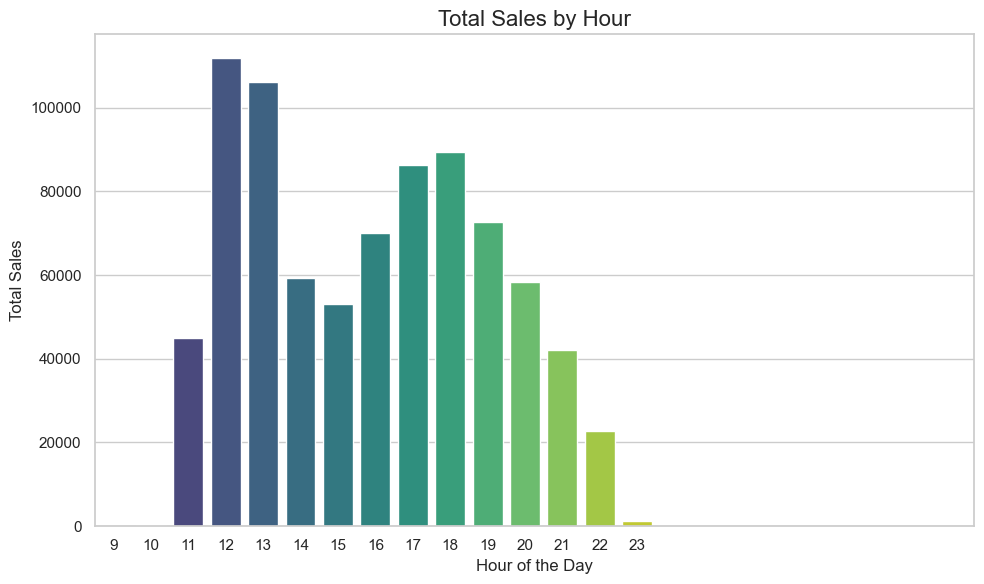

In [233]:
# Visualise the Peak hours 
# Set the plot style

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.barplot(data=peak_hours,x='hour',y='total_price',palette='viridis')

plt.title('Total Sales by Hour', fontsize=16)
plt.xlabel('Hour of the Day')
plt.ylabel('Total Sales')
plt.xticks(range(24)) # Display all hours from 0 - 23
plt.tight_layout()

plt.show



In [234]:
#Total Sales by Day of the Week
df['day_of_week'] = df['date'].dt.day_name()
day_sales=df.groupby('day_of_week')['total_price'].sum().sort_values(ascending=False).reset_index()
day_sales.index = day_sales.index + 1
day_sales.index.name = "Rank"

print("Sales by Day of Week:\n", day_sales)

Sales by Day of Week:
      day_of_week  total_price
Rank                         
1         Friday    136073.90
2       Thursday    123528.50
3       Saturday    123182.40
4      Wednesday    114408.40
5        Tuesday    114133.80
6         Monday    107329.55
7         Sunday     99203.50


<function matplotlib.pyplot.show(close=None, block=None)>

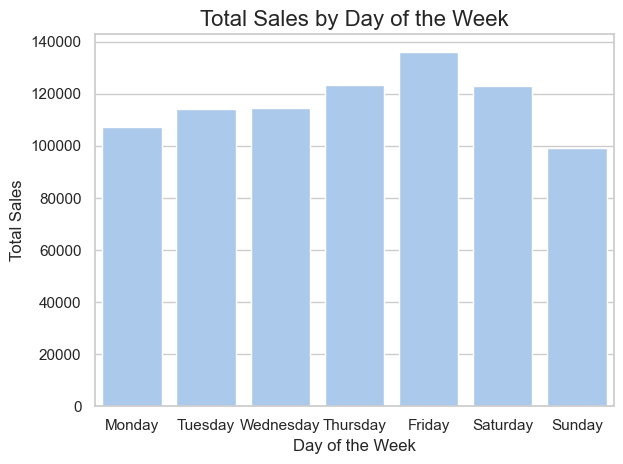

In [235]:
#visualise  Total sales

order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]
sns.set_theme(style="whitegrid", palette="pastel")
sns.barplot(data= day_sales, x = 'day_of_week',y = 'total_price', order=order)
plt.title('Total Sales by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales')

plt.tight_layout()

plt.show


In [236]:
# Top 5 Bestselling Pizzas
top_5_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5).reset_index()
top_5_pizzas.index = top_5_pizzas.index + 1
top_5_pizzas.index.name = "Rank"
print("Top 5 Pizzas:\n", top_5_pizzas)

Top 5 Pizzas:
                             name  quantity
Rank                                      
1       The Classic Deluxe Pizza      2453
2     The Barbecue Chicken Pizza      2432
3             The Hawaiian Pizza      2422
4            The Pepperoni Pizza      2418
5         The Thai Chicken Pizza      2371


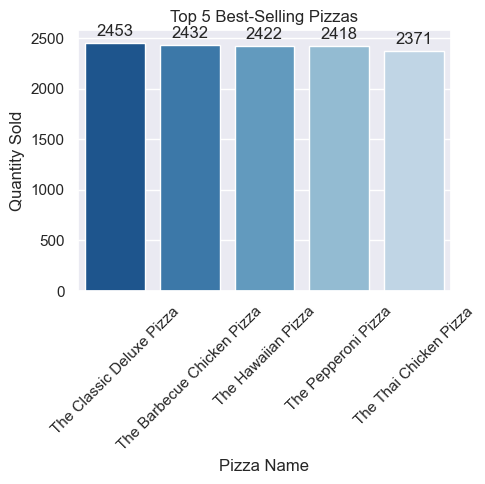

In [237]:
sns.set_theme(style="darkgrid", palette='Blues_r')

plt.figure(figsize=(5, 5))

ax = sns.barplot(
    data=top_5_pizzas,
    x='name',
    y='quantity',
    hue='name',      # avoids FutureWarning
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title("Top 5 Best-Selling Pizzas")
plt.xlabel("Pizza Name")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Sales made in Each month:
         month     price
4     January  68472.70
3    February  64067.40
7       March  69198.00
0       April  67286.20
8         May  69939.35
6        June  66796.30
5        July  71027.45
1      August  67068.80
11  September  63018.00
10    October  62566.50
9    November  69054.00
2    December  63450.00


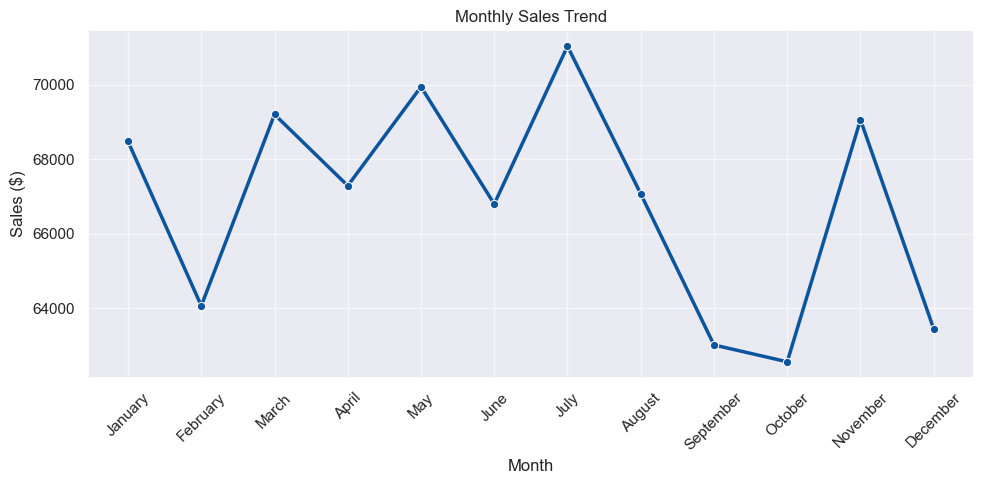

In [238]:
# Sales Made in Each month(Trends)
# convert date to month name
df['month'] = df['date'].dt.month_name()

# Define month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Calculate sales by month
month_sales = df.groupby('month', as_index=False)['price'].sum()

# set month order
month_sales['month'] = pd.Categorical(month_sales['month'], categories=month_order, ordered = True)
    
# Sort Chronolically 
month_sales = month_sales.sort_values('month')
print("Sales made in Each month:\n", month_sales )

# Plot

plt.figure(figsize = (10,5))
sns.lineplot(data=month_sales, x='month', y='price', marker='o',linewidth=2.5)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.grid(True,alpha=0.6)
plt.tight_layout()
plt.show()

Top 5 pizzas not doing well:
                            name  quantity
Rank                                     
1          The Brie Carre Pizza       490
2       The Mediterranean Pizza       934
3           The Calabrese Pizza       937
4     The Spinach Supreme Pizza       950
5         The Soppressata Pizza       961


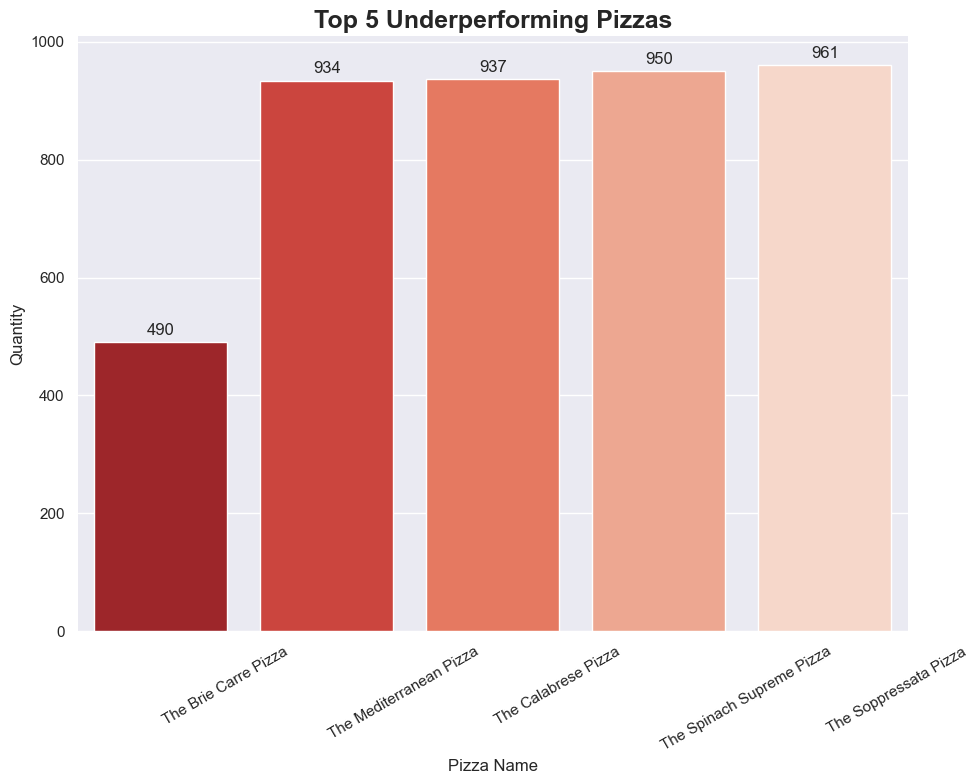

In [239]:
# Pizzas Types Not Doing well (Bottom Sallers)
bottom_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=True).reset_index().head(5)
bottom_pizzas.index = bottom_pizzas.index + 1
bottom_pizzas.index.name = "Rank"
print("Top 5 pizzas not doing well:\n", bottom_pizzas)


plt.figure(figsize=(10,8))
ax = sns.barplot(data=bottom_pizzas, x='name', y='quantity', palette="Reds_r", hue="name", legend= False)
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Top 5 Underperforming Pizzas", fontsize=18, weight="bold")
plt.xlabel("Pizza Name", fontsize=12)
plt.ylabel("Quantity",fontsize=12)
plt.xticks(rotation=30, ha='left')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

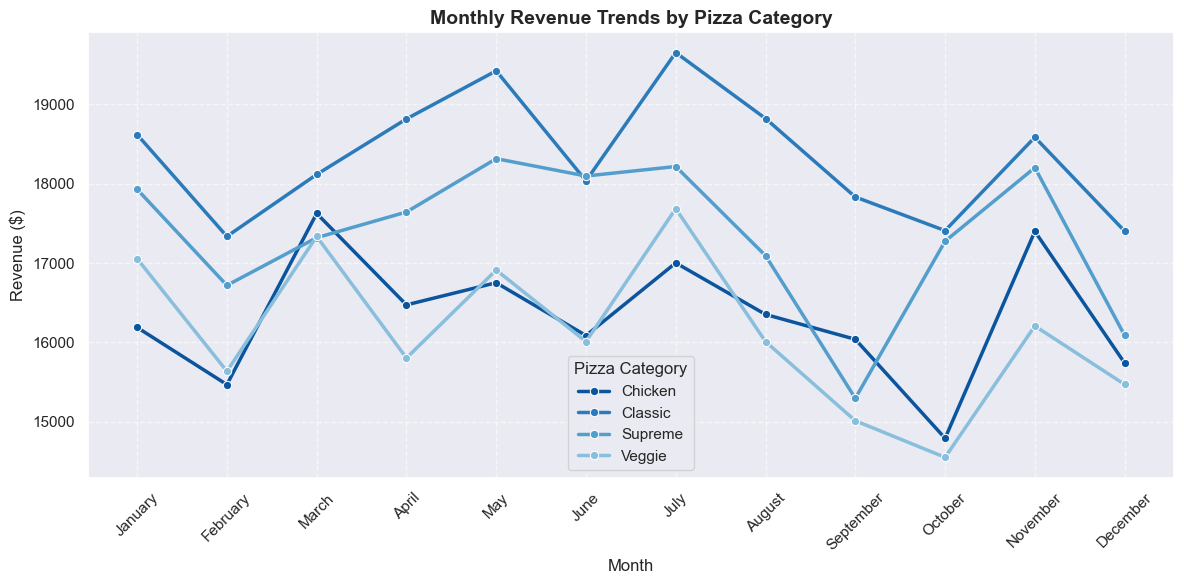

In [240]:
# Group by Month and Category to get Total revenue

# Define month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]


df['month'] = df['date'].dt.month_name()
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)


category_trend =df.groupby(['month', 'category'])['total_price'].sum().reset_index()

#Pivot data for easier visualization plotting 
pivot_df = category_trend.pivot(index='month', columns='category', values='total_price')


plt.figure(figsize=(12,6))
sns.lineplot(data=category_trend, x='month', y='total_price', hue='category', marker='o', linewidth=2.5)
plt.title('Monthly Revenue Trends by Pizza Category', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Pizza Category')
plt.tight_layout()
plt.show()

## Insight 

The Classic pizza category is the top revenue contributor, reaching nearly $20,000 in July. 

October marks the weakest sales period, with Chicken, Veggie, and Supreme hitting yearly lows. 

June shows a unique trend, as Chicken and Veggie maintain stability while Classic and Supreme decline, making Chicken the strongest performer during this transition.

C:\Users\Hp\AppData\Local\Temp\ipykernel_46100\4224245392.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(month_order, rotation=45)


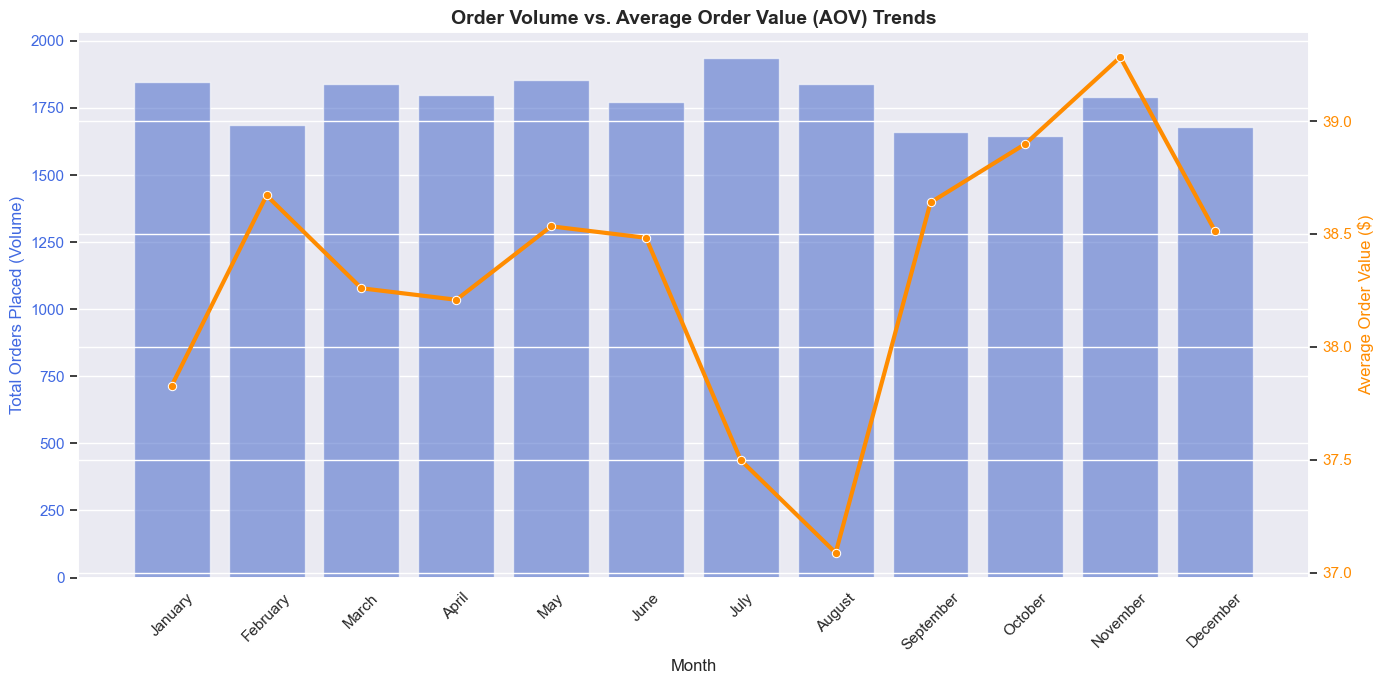

In [241]:
df['total_price']
# Group by month to calculate total revenue and unique Order count
monthly_metrics = df.groupby('month', observed=False).agg(total_revenue=('total_price','sum'), 
                                                          total_orders=('order_id','nunique')).reset_index()
# Calculate Average Order Value(AOV)
monthly_metrics['aov'] = monthly_metrics['total_revenue']/monthly_metrics['total_orders']

# Visualization
fig, ax1 = plt.subplots(figsize=(14,7))

# Plotting Order Volume (bars)

sns.barplot(data=monthly_metrics, x='month', y='total_orders', alpha=0.6, color='royalblue', ax= ax1)
ax1.set_title('Order Volume vs. Average Order Value (AOV) Trends', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Orders Placed (Volume)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(month_order, rotation=45)


# Creating a second y-axis for AOV
ax2 = ax1.twinx()

# Plotting Average Order Value (Line)
sns.lineplot(data=monthly_metrics, x='month', y='aov', color='darkorange', marker='o', linewidth=3, sort=False, ax=ax2)
ax2.set_ylabel('Average Order Value ($)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.tight_layout()
plt.show()

**Average Order Value (AOV) Insights:**
The restaurant’s revenue fluctuations are driven more by changes in Average Order Value (AOV) than by order volume. 

Although July records the highest number of orders, revenue growth is limited because AOV drops to around **$37.50**, indicating customers are placing smaller, lower-value orders. 

This trend continues in August, where AOV reaches its lowest level of approximately **$37.10**, reducing overall revenue despite strong customer demand. 

Conversely, AOV rises sharply from September through November, peaking at over **$39.20** in November. As a result, November generates one of the highest revenue totals even with fewer orders than July. 

These patterns suggest clear seasonal shifts in customer purchasing behavior. 

During the summer months, customers tend to buy lower-priced or fewer items, while in late autumn they spend more per transaction, likely purchasing larger pizzas, premium toppings, bundles, or group meals, resulting in stronger overall revenue.

**Pizzas Sales are cyclical because of shifting customer ordering habits across different seasons.**

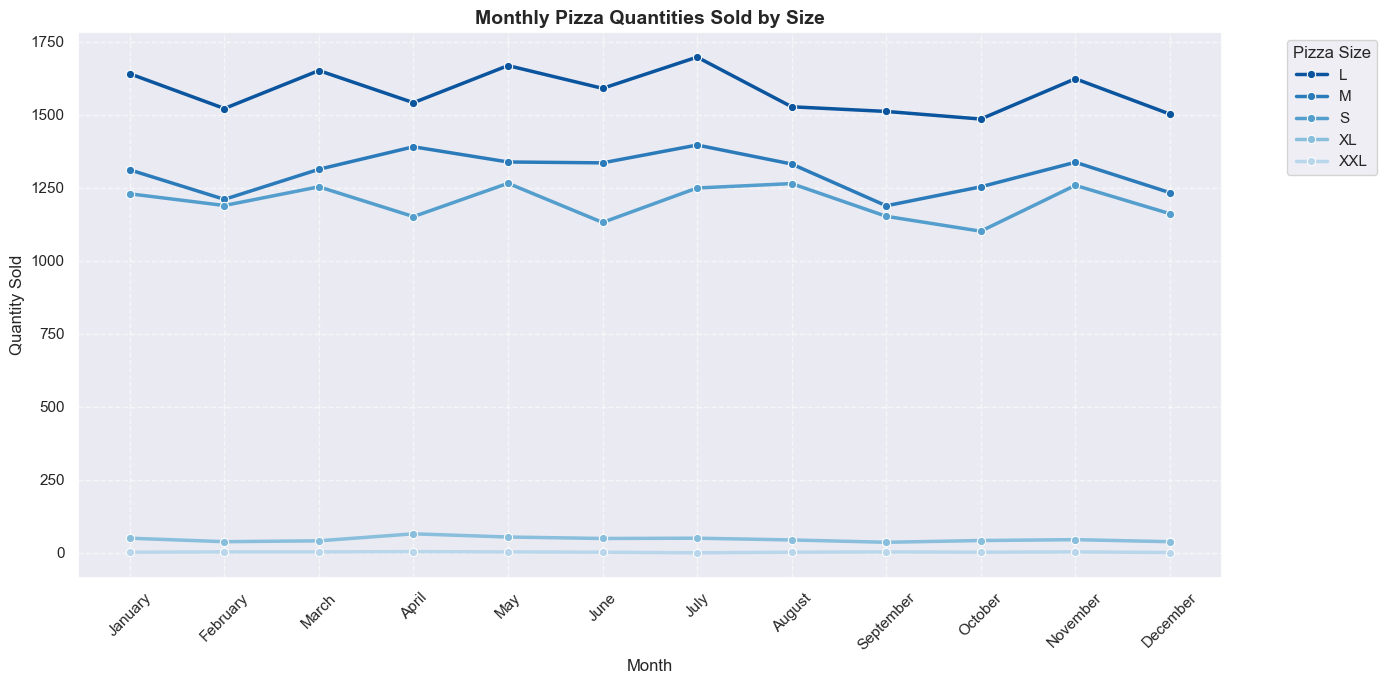

In [244]:
# using the Pizza size to understand the spending habit

# group by month and pizza size to get  
size_trend = df.groupby(['month','size'], observed =False)['quantity'].sum().reset_index()

# pivot data for plotting

pivot_size = size_trend.pivot(index='month', columns='size', values='quantity').sort_index()


# Visualization

plt.figure(figsize=(14,7))
sns.lineplot(data=size_trend, x='month', y='quantity', hue='size', marker='o', linewidth=2.5)
plt.title('Monthly Pizza Quantities Sold by Size', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Pizza Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Pizza Size Preference Insights:**
Customer size preferences remain remarkably consistent throughout the year, with **Large (L)** pizzas consistently recording the highest sales volume of approximately **1,500–1,700 units per month**. 

**Medium (M)** and **Small (S)** sizes maintain steady demand at similar levels, while **XL** and **XXL** contribute only a minimal share of total sales. 

The absence of significant seasonal shifts in size preferences indicates that customers do not alter their pizza size choices across different periods of the year. 

This suggests that changes in revenue are driven more by variations in order value, product mix, or purchase frequency than by changes in pizza size demand.


**Final Business Insight:**
The sharp fluctuations in Average Order Value (AOV) are most likely driven by the number of pizzas purchased per transaction rather than changes in customer volume, pizza category, or size preferences. 


Promoting group meal bundles in autumn and multi-buy offers during summer can increase order quantities, improve AOV, and maximize revenue.



**Why don't we validate this**


That changes in revenue are driven more by variations in order value, product mix, or purchase frequency than by changes in pizza size demand.

# Calculate the average number of pizzas per order ID for each month
quantity_per_order = df.groupby(['month', 'order_id'], observed=False)['quantity'].sum().reset_index()
monthly_avg_qty = quantity_per_order.groupby('month', observed=False)['quantity'].mean().reset_index()

# Plot the result
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_avg_qty, x='month', y='quantity', marker='o', color='crimson', linewidth=2.5)
plt.title('Average Number of Pizzas Placed Per Order', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg. Pizzas per Transaction')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

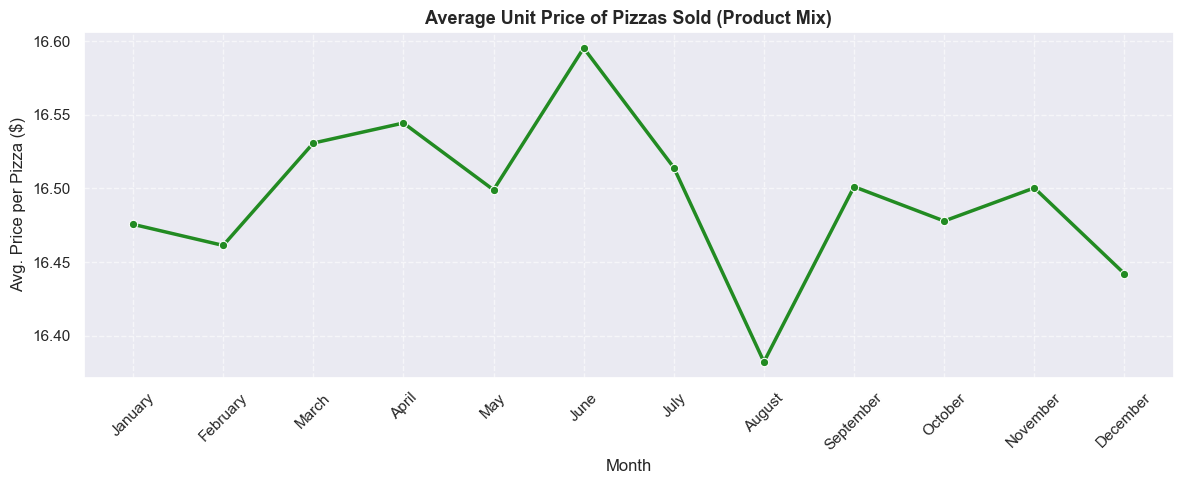

In [247]:
# Calculate the average price of a single pizza unit sold each month
monthly_avg_unit_price = df.groupby('month', observed=False)['price'].mean().reset_index()

# Plot the result
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_avg_unit_price, x='month', y='price', marker='o', color='forestgreen', linewidth=2.5)
plt.title('Average Unit Price of Pizzas Sold (Product Mix)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg. Price per Pizza ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Validation Verdict: The highly cyclical nature of the restaurant's monthly sales is primarily a function of shifting consumer spending choices (Product Mix) and individual transaction behavior, rather than a changes in pizza size demand.